In [1]:
import helpers
import importlib
from matplotlib.ticker import ScalarFormatter
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
case_df = pd.read_excel("cases.xlsx")
case_df.head()

,case,solution_method,time_scheme,conv_scheme,RE,N,DX,DT_MAX,DT,CFL,URFP,URFU,diverging_factor,IT,clock_time,colour,compare_diff,plot,Coldumn3,Time (min)
0,1,EFSM,1.0,UDS,1000,16,0.062500,0.062500,0.1500,2.400,NaN,-1.0,0.2000,260.0,0.247447,C0,16.666667,25.0,10.4000,0.004124
1,2,EFSM,1.0,UDS,1000,32,0.031250,0.031250,0.0500,1.600,NaN,-1.0,0.1000,860.0,3.887910,C0,50.000000,100.0,8.6000,0.064799
2,3,EFSM,1.0,UDS,1000,64,0.015625,0.015625,0.0150,0.960,NaN,-1.0,0.0200,3322.0,44.980831,C0,166.666667,250.0,13.2880,0.749681
3,4,EFSM,1.0,UDS,1000,128,0.007812,0.007812,0.0050,0.640,NaN,-1.0,0.0100,11952.0,377.196014,C0,500.000000,1000.0,11.9520,6.286600
4,5,EFSM,1.0,UDS,1000,256,0.003906,0.003906,0.0015,0.384,NaN,-1.0,0.0025,43836.0,3393.875980,C1,1666.666667,5000.0,8.7672,56.564600


In [2]:
importlib.reload(helpers)
CavityCase = helpers.CavityCase
CaseManager = helpers.CaseManager

case9=CavityCase(9)
case95=CavityCase(95)

In [3]:
case94 = CavityCase(94)

In [4]:
case95.res_df

,IT,N,RESORM,RESORU,RESORV
0,20,6179,0.000100,9.376074,3.758442
1,40,1448,0.000100,6.078724,2.724644
2,60,937,0.000100,4.698726,2.362023
3,80,727,0.000100,3.929281,2.232470
4,100,631,0.000100,3.442156,2.199837
...,...,...,...,...,...
591,11840,1,0.000015,0.000519,0.000485
592,11860,1,0.000015,0.000511,0.000476
593,11880,1,0.000015,0.000501,0.000467
594,11900,1,0.000015,0.000502,0.000469


EFSM
SIMPLE


Text(0.5, 1.0, 'Comparison of Residuals (QUICK, Re=1000, N=128)')

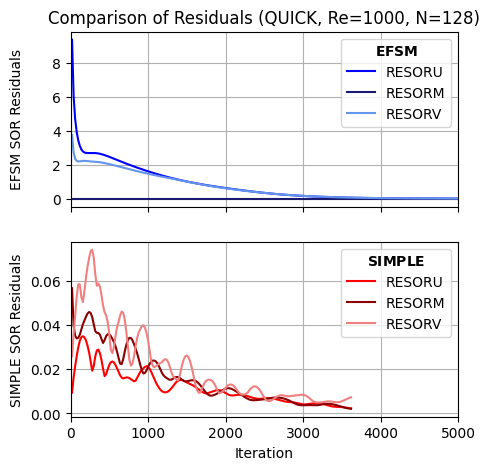

In [5]:
fig, axes = plt.subplots(2,1,figsize=(5,5),sharex=True)
simple_case = case94
efsm_case=case95
cases = {
    "EFSM": efsm_case,
    "SIMPLE": simple_case
}

colors_dict = {
    "EFSM": {
             "RESORU": "blue",
             "RESORV": "cornflowerblue",
             "RESORM": "midnightblue"
             },
    "SIMPLE": {
             "RESORU": "red",
             "RESORV": "lightcoral",
             "RESORM": "darkred"
             },
}
for i,(solver,case) in enumerate(cases.items()):
    print(solver)
    ax=axes[i]
    colors=colors_dict[solver]
    res_df=case.res_df.dropna()
    ax.plot(res_df["IT"],res_df["RESORU"], linestyle='-',  label="RESORU", color=colors["RESORU"])
    ax.plot(res_df["IT"],res_df["RESORM"], linestyle='-', label="RESORM", color=colors["RESORM"])
    ax.plot(res_df["IT"],res_df["RESORV"], linestyle='-', label="RESORV", color=colors["RESORV"])
    ax.grid()
    ax.legend(title=rf"$\bf{{{solver}}}$")
    ax.set_ylabel(f"{solver} SOR Residuals")
    ax.yaxis.set_label_coords(-0.12, 0.5) 
    ax.set_xlim(0, 5000)
axes[1].set_xlabel("Iteration")
axes[0].set_title("Comparison of Residuals (QUICK, Re=1000, N=128)")

EFSM
SIMPLE


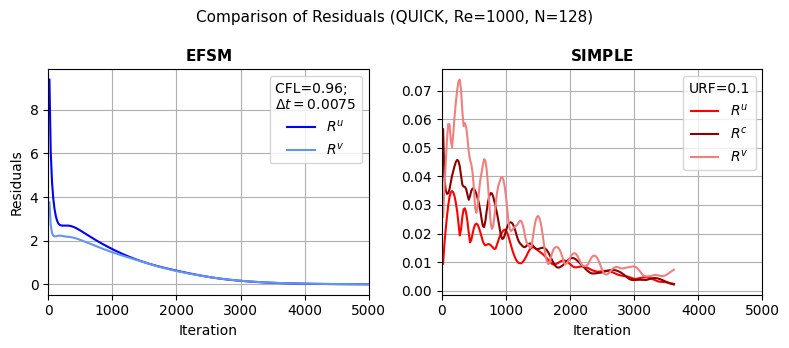

In [11]:
fig, axes = plt.subplots(1,2,figsize=(8,3.5),sharex=True)
simple_case = case94
efsm_case=case95
cases = {
    "EFSM": efsm_case,
    "SIMPLE": simple_case
}
labels={
    "EFSM": "CFL=0.96; \n"+r"$\Delta t=0.0075$",
    "SIMPLE": "URF=0.1"
}
colors_dict = {
    "EFSM": {
             "RESORU": "blue",
             "RESORV": "cornflowerblue",
             "RESORM": "midnightblue"
             },
    "SIMPLE": {
             "RESORU": "red",
             "RESORV": "lightcoral",
             "RESORM": "darkred"
             },
}
for i,(solver,case) in enumerate(cases.items()):
    print(solver)
    ax=axes[i]
    colors=colors_dict[solver]
    res_df=case.res_df.dropna()
    ax.plot(res_df["IT"],res_df["RESORU"], linestyle='-',  label=r"$R^u$", color=colors["RESORU"])
    if solver=="SIMPLE":
        ax.plot(res_df["IT"],res_df["RESORM"], linestyle='-', label=r"$R^c$", color=colors["RESORM"])
    ax.plot(res_df["IT"],res_df["RESORV"], linestyle='-', label=r"$R^v$", color=colors["RESORV"])
    ax.grid()
    ax.legend(title=labels[solver])
    ax.set_title(rf"$\bf{{{solver}}}$", fontsize=11)
    ax.set_xlim(0, 5000)
    ax.set_xlabel("Iteration")
fig.suptitle("Comparison of Residuals (QUICK, Re=1000, N=128)",fontsize=11)
axes[0].set_ylabel(f"Residuals")
fig.tight_layout()
    # ax.yaxis.set_label_coords(-0.12, 0.5) 

Text(0, 0.5, 'Residual')

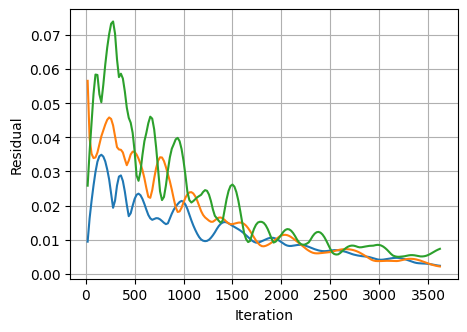

In [7]:
fig, ax = plt.subplots(1,1,figsize=(5,3.5))
simple_case = case94
res_df=simple_case.res_df
ax.plot(res_df["IT"],res_df["RESORU"],  label="Residual")
ax.plot(res_df["IT"],res_df["RESORM"],  label="Residual")
ax.plot(res_df["IT"],res_df["RESORV"],  label="Residual")
ax.grid()
ax.set_xlabel("Iteration")
ax.set_ylabel("Residual")